In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0 --index-url https://download.pytorch.org/whl/cpu


In [ ]:

import torch
print(torch.__version__)


In [ ]:


import torchvision

torchvision.__version__


In [ ]:
import pandas as pd

In [ ]:
balanced_df = pd.read_csv('/content/drive/MyDrive/Copy of balanced_data.csv')
balanced_df.shape

(762583, 34)

In [ ]:
balanced_df['Attack Number'].unique()

array([0, 4, 3, 7, 2, 8, 1])

In [ ]:
# Check unique labels and their counts
print("Label distribution:")
print(balanced_df['Attack Number'].value_counts().sort_index())

# Ensure labels are 0-indexed and continuous
balanced_df['Attack Number'] = balanced_df['Attack Type'].astype('category').cat.codes
print("\nCorrected labels:")
print(balanced_df['Attack Number'].value_counts().sort_index())

Label distribution:
Attack Number
0    200000
1     50000
2     50000
3    128016
4    193748
7     90819
8     50000
Name: count, dtype: int64

Corrected labels:
Attack Number
0    200000
1     50000
2     50000
3    128016
4    193748
5     90819
6     50000
Name: count, dtype: int64


In [ ]:

attack_counts = balanced_df.groupby('Attack Type')['Attack Number'].agg(['count', 'unique']).reset_index()
attack_counts


,Attack Type,count,unique
0,BENIGN,200000,[0]
1,Bot,50000,[1]
2,Brute Force,50000,[2]
3,DDoS,128016,[3]
4,DoS,193748,[4]
5,Port Scan,90819,[5]
6,Web Attack,50000,[6]


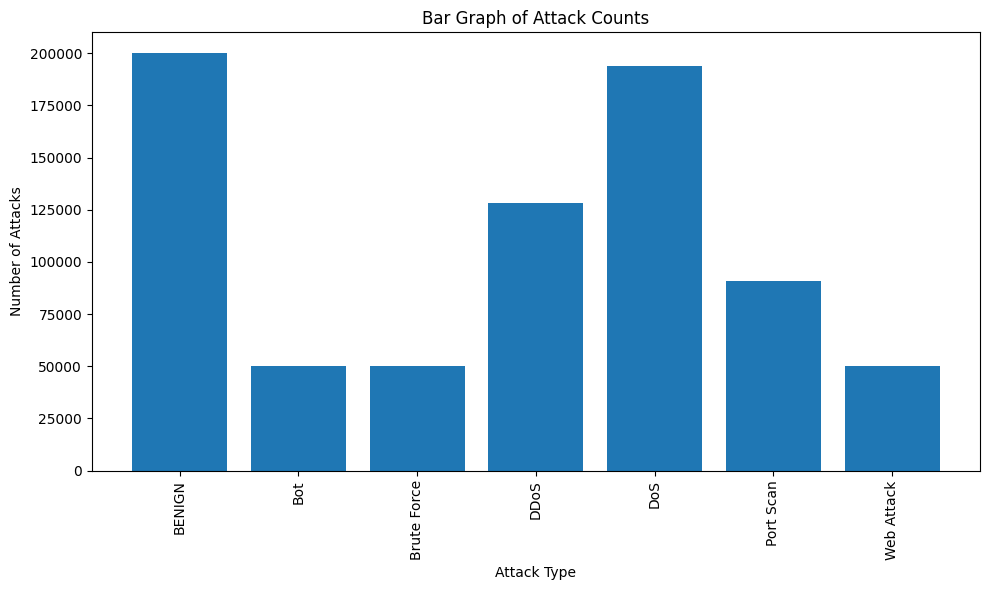

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'attack_counts' DataFrame from the previous code is available

plt.figure(figsize=(10, 6))  # Adjust figure size for better readability
plt.bar(attack_counts['Attack Type'], attack_counts['count'])
plt.xlabel('Attack Type')
plt.ylabel('Number of Attacks')
plt.title('Bar Graph of Attack Counts')
plt.xticks(rotation=90) # Rotate x-axis labels for better visibility if needed
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


In [ ]:
from sklearn.utils import shuffle

# Shuffle the entire dataset while preserving feature-label relationships
balanced_df = shuffle(balanced_df, random_state=42)

# Verify shuffle
print(balanced_df['Attack Type'].head(10))  # Should show mixed classes

327513            DoS
695518    Brute Force
95838          BENIGN
280286            DoS
320022            DoS
93475          BENIGN
718112     Web Attack
669333            Bot
611100      Port Scan
169116         BENIGN
Name: Attack Type, dtype: object


In [ ]:

attack_counts11 = balanced_df.groupby('Attack Type')['Attack Number'].agg(['count', 'unique']).reset_index()
attack_counts11


,Attack Type,count,unique
0,BENIGN,200000,[0]
1,Bot,50000,[1]
2,Brute Force,50000,[2]
3,DDoS,128016,[3]
4,DoS,193748,[4]
5,Port Scan,90819,[5]
6,Web Attack,50000,[6]


In [ ]:
balanced_df.head(-10)

,Flow Duration,Bwd Packet Length Max,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,...,Avg Bwd Segment Size,Init_Win_bytes_forward,Active Mean,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Number,Attack Type
327513,69155560,4344,1449.375000,1729.380148,5.762963e+06,1.990000e+07,69000000,1,69000000,1.720000e+07,...,1449.375000,0,10996.0,10996,69000000.0,0.0,69000000,69000000,4,DoS
695518,12629111,976,85.781250,220.240592,2.428675e+05,6.618727e+05,2509237,16,10900000,5.457126e+05,...,85.781250,29200,0.0,0,0.0,0.0,0,0,2,Brute Force
95838,5904238,1493,552.625000,690.541803,3.280132e+05,1.319836e+06,5615778,2,5904238,5.904238e+05,...,552.625000,29200,288458.0,288458,5615778.0,0.0,5615778,5615778,0,BENIGN
280286,98685972,2907,1656.428571,1549.451931,8.223831e+06,2.850000e+07,98600000,2,98600000,1.970000e+07,...,1656.428571,0,14006.0,14006,98600000.0,0.0,98600000,98600000,4,DoS
320022,85644076,8688,1932.500000,3506.021777,8.564408e+06,2.700000e+07,85500000,50,85500000,2.140000e+07,...,1932.500000,0,9001.0,9001,85500000.0,0.0,85500000,85500000,4,DoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278167,98239676,5792,1932.500000,2181.008184,7.556898e+06,2.720000e+07,98200000,0,98200000,1.400000e+07,...,1932.500000,274,984.0,984,98200000.0,0.0,98200000,98200000,4,DoS
191335,5176629,0,0.000000,0.000000,1.725543e+06,2.975673e+06,5161543,57,5176629,2.588314e+06,...,0.000000,29200,0.0,0,0.0,0.0,0,0,0,BENIGN
175203,23786,211,211.000000,0.000000,7.928667e+03,1.368784e+04,23734,4,48,4.800000e+01,...,211.000000,-1,0.0,0,0.0,0.0,0,0,0,BENIGN
87498,51,2,2.000000,0.000000,1.700000e+01,1.345362e+01,28,2,51,5.100000e+01,...,2.000000,0,0.0,0,0.0,0.0,0,0,0,BENIGN


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler  # Optional scaling

# Assuming balanced_df is already loaded and preprocessed

# 1. Separate features (X) and labels (y)
X = balanced_df.drop(['Attack Type', 'Attack Number'], axis=1)
y = balanced_df['Attack Number']

# 2. Optional: Scale the features to [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train-test split (with stratified class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,  # Use X instead of X_scaled if you don't want scaling
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintains class balance in train and test sets
)

# 4. Reshape data for TSANet input: (samples, timesteps, features)
X_train = X_train.reshape(-1, 32, 1)
X_test = X_test.reshape(-1, 32, 1)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (610066, 32, 1), Test shape: (152517, 32, 1)


In [ ]:
import tensorflow as tf
!pip install -q tensorflow-model-optimization
import tensorflow_model_optimization as tfmot
from sklearn.utils.class_weight import compute_class_weight
import numpy as np



AttributeError: module 'numpy' has no attribute 'dtypes'

In [ ]:
tf.__version__

In [ ]:
# Make sure X_train, X_test, y_train, y_test are already loaded
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

num_classes = 7


In [ ]:
import torch
import torch.nn as nn

class TSANet(nn.Module):
    def __init__(self, input_shape=(32, 1), num_classes=7):
        super(TSANet, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.spatial_att = nn.Conv1d(32, 1, kernel_size=1)

        self.temporal_lstm = nn.LSTM(input_size=32, hidden_size=32, batch_first=True)
        self.temporal_att_dense = nn.Linear(32, 1)

        self.batch_norm = nn.BatchNorm1d(64)
        self.lstm_final = nn.LSTM(input_size=64, hidden_size=64, batch_first=True)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x_conv = self.relu(self.conv1(x))

        spatial_att = torch.sigmoid(self.spatial_att(x_conv))
        spatial_out = x_conv * spatial_att

        x_lstm_input = x_conv.permute(0, 2, 1)
        temporal_out, _ = self.temporal_lstm(x_lstm_input)
        att_weights = torch.softmax(self.temporal_att_dense(temporal_out), dim=1)
        temporal_out = x_lstm_input * att_weights

        spatial_out = spatial_out.permute(0, 2, 1)
        combined = torch.cat((spatial_out, temporal_out), dim=-1)
        combined = self.batch_norm(combined.permute(0, 2, 1))
        combined = combined.permute(0, 2, 1)

        lstm_out, _ = self.lstm_final(combined)
        final_features = lstm_out[:, -1, :]
        out = self.classifier(final_features)
        return out


In [ ]:
import torch
print(torch.__version__)
import numpy

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)
model = TSANet(num_classes=7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


optimizer = optim.Adam(model.parameters(), lr=1e-3)


epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/total:.4f}, Accuracy: {100 * correct / total:.2f}%")


In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.24.3


In [ ]:
import numpy as np
import torch
print("NumPy version:", np.__version__)
print("Torch version:", torch.__version__)


In [ ]:



train_accuracies = []

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_accuracy = 100 * correct / total
    train_accuracies.append(epoch_accuracy)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/total:.4f}, Accuracy: {epoch_accuracy:.2f}%")


Epoch 1/10, Loss: 0.4094, Accuracy: 83.94%
Epoch 2/10, Loss: 0.1145, Accuracy: 95.03%
Epoch 3/10, Loss: 0.0858, Accuracy: 96.30%
Epoch 4/10, Loss: 0.0693, Accuracy: 97.02%
Epoch 5/10, Loss: 0.0663, Accuracy: 97.15%
Epoch 6/10, Loss: 0.0574, Accuracy: 97.53%
Epoch 7/10, Loss: 0.0554, Accuracy: 97.64%
Epoch 8/10, Loss: 0.0515, Accuracy: 97.83%
Epoch 9/10, Loss: 0.0493, Accuracy: 97.94%
Epoch 10/10, Loss: 0.0449, Accuracy: 98.14%


In [ ]:
import torch

# Always use CPU for Android models
device = torch.device('cpu')
model = model.to(device)
model.eval()

# Make sure dummy input is also on CPU
example_input = torch.randn(1, 32, 1).to(device)

# Trace the model using CPU tensors
traced_model = torch.jit.trace(model, example_input)

# Save the traced model
traced_model.save("tsanet_model_android_cpu.pt")

print("✅ CPU-compatible model saved as 'tsanet_model_android_cpu.pt'")


In [ ]:
# Set the model to evaluation mode
model.eval()

# Initialize variables to track the test loss and accuracy
test_running_loss = 0.0
test_correct = 0
test_total = 0

# Disable gradient calculation for testing
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass: Get model predictions
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(outputs, y_batch)
        test_running_loss += loss.item() * X_batch.size(0)

        # Get the predicted class
        _, predicted = torch.max(outputs, 1)

        # Update the count of correct predictions
        test_correct += (predicted == y_batch).sum().item()
        test_total += y_batch.size(0)

# Calculate average test loss and accuracy
average_test_loss = test_running_loss / test_total
test_accuracy = 100 * test_correct / test_total

# Print the test results
print(f"Test Loss: {average_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")


Test Loss: 0.0607, Test Accuracy: 97.35%


In [ ]:
import torch.nn.utils.prune as prune

# Step 1: Define which layers you want to prune
modules_to_prune = (
    (model.conv1, 'weight'),       # Conv1d layer
    (model.spatial_att, 'weight'),  # Spatial attention conv
    (model.temporal_att_dense, 'weight'),  # Linear attention
    (model.classifier, 'weight'),   # Final classifier Linear
)

# Step 2: Apply L1 Unstructured Pruning
for module, param in modules_to_prune:
    prune.l1_unstructured(module, name=param, amount=0.3)
    # 'amount' = fraction of weights to prune (30% here)

print("✅ Pruning Applied!")

# Step 3: Fine-tune again for 5–10 epochs to recover slight accuracy loss
fine_tune_epochs = 5
for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    print(f"[Fine-tune] Epoch {epoch+1}/{fine_tune_epochs}, Loss: {running_loss/total:.4f}, Accuracy: {100 * correct / total:.2f}%")

# Step 4 (Optional): To permanently prune the weights (remove masks)
for module, param in modules_to_prune:
    prune.remove(module, param)

print("✅ Pruning Masks Removed! Model is now smaller.")

# Save final pruned model
traced_model = torch.jit.trace(model, example_input)
traced_model.save("tsanet_model_android_pruned.pt")
print("✅ Pruned model saved as 'tsanet_model_android_pruned.pt'")

✅ Pruning Applied!
[Fine-tune] Epoch 1/5, Loss: 0.0450, Accuracy: 98.08%
[Fine-tune] Epoch 2/5, Loss: 0.0443, Accuracy: 98.14%
[Fine-tune] Epoch 3/5, Loss: 0.0425, Accuracy: 98.22%
[Fine-tune] Epoch 4/5, Loss: 0.0429, Accuracy: 98.18%
[Fine-tune] Epoch 5/5, Loss: 0.0405, Accuracy: 98.29%
✅ Pruning Masks Removed! Model is now smaller.
✅ Pruned model saved as 'tsanet_model_android_pruned.pt'


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Step 1: Move model to CPU (required for Android Studio)
device = torch.device('cpu')
model = model.to(device)

# Step 2: Manually prune (zero-out) 30% smallest-magnitude weights per layer
def manual_l1_prune(tensor, amount=0.3):
    tensor_flat = tensor.view(-1)
    num_prune = int(amount * tensor_flat.numel())
    if num_prune == 0:
        return  # Skip if not enough weights
    threshold = torch.topk(torch.abs(tensor_flat), num_prune, largest=False).values.max()
    tensor.data[torch.abs(tensor) <= threshold] = 0

# List of target layers
target_layers = [model.conv1.weight,
                 model.spatial_att.weight,
                 model.temporal_att_dense.weight,
                 model.classifier.weight]

for weight_tensor in target_layers:
    manual_l1_prune(weight_tensor, amount=0.3)

print("✅ Manual pruning complete!")

# Step 3: Fine-tune on CPU for 5 epochs
fine_tune_epochs = 5
model.train()

for epoch in range(fine_tune_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    print(f"[Fine-tune] Epoch {epoch+1}/{fine_tune_epochs}, Loss: {running_loss/total:.4f}, Accuracy: {100 * correct / total:.2f}%")

# Step 4: Save CPU-traced version for Android Studio
model.eval()
example_input = torch.randn(1, 32, 1).to(device)
traced_model = torch.jit.trace(model, example_input)
traced_model.save("tsanet_model_android_pruned.pt")

print("✅ Final pruned model saved as 'tsanet_model_android_pruned.pt'")


✅ Manual pruning complete!
[Fine-tune] Epoch 1/5, Loss: 0.0450, Accuracy: 98.14%
[Fine-tune] Epoch 2/5, Loss: 0.0453, Accuracy: 98.13%
[Fine-tune] Epoch 3/5, Loss: 0.0429, Accuracy: 98.21%
[Fine-tune] Epoch 4/5, Loss: 0.0421, Accuracy: 98.28%
[Fine-tune] Epoch 5/5, Loss: 0.0417, Accuracy: 98.30%
✅ Final pruned model saved as 'tsanet_model_android_pruned.pt'


In [ ]:
import torch
import time

# Load TorchScript model
model = torch.jit.load('/content/tsanet_model_android_cpu.pt')
model.eval()

# Detect device
device = torch.device('cpu')
model = model.to(device)

# Correct dummy input
dummy_input = torch.randn(1, 32, 1).to(device)  # Move input to same device!

# Warm-up
for _ in range(10):
    _ = model(dummy_input)

# Measure inference time
start_time = time.time()
output = model(dummy_input)
end_time = time.time()

inference_time_ms = (end_time - start_time) * 1000
print(f"Inference Time: {inference_time_ms:.4f} ms per sample")


Inference Time: 1.6408 ms per sample


In [ ]:
import torch
import time

# Load TorchScript model
model = torch.jit.load('/content/tsanet_model_android_pruned.pt')
model.eval()

# Detect device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Correct dummy input
dummy_input = torch.randn(1, 32, 1).to(device)  # Move input to same device!

# Warm-up
for _ in range(10):
    _ = model(dummy_input)

# Measure inference time
start_time = time.time()
output = model(dummy_input)
end_time = time.time()

inference_time_ms = (end_time - start_time) * 1000
print(f"Inference Time: {inference_time_ms:.4f} ms per sample")


Inference Time: 0.9246 ms per sample


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Assume X_train, X_test, y_train, and y_test are already defined as tensors or pandas DataFrames

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

# Define the TSANet model (assuming this is already implemented somewhere)
model = TSANet(num_classes=7)
device = torch.device("cpu")  # Force to use CPU for Android deployment
model.to(device)

# Compute class weights (if needed)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/total:.4f}, Accuracy: {100 * correct / total:.2f}%")

# To save the model in PyTorch Lite format, use torch.jit.trace and save as .ptl
# Make sure to use a CPU-based example input
example_input = torch.randn(1, 32, 1).to(device)  # Adjust shape as needed for your model
traced_model = torch.jit.trace(model, example_input)

# Save the model as a PyTorch Lite model (.ptl)
traced_model.save("tsanet_model_android.ptl")
print("Trained and saved as 'tsanet_model_android.ptl'")


Epoch 1/10, Loss: 0.3667, Accuracy: 85.64%
Epoch 2/10, Loss: 0.1436, Accuracy: 93.96%
Epoch 3/10, Loss: 0.0819, Accuracy: 96.48%
Epoch 4/10, Loss: 0.0732, Accuracy: 96.86%
Epoch 5/10, Loss: 0.0676, Accuracy: 97.11%
Epoch 6/10, Loss: 0.0598, Accuracy: 97.41%
Epoch 7/10, Loss: 0.0583, Accuracy: 97.48%
Epoch 8/10, Loss: 0.0539, Accuracy: 97.72%
Epoch 9/10, Loss: 0.0511, Accuracy: 97.88%
Epoch 10/10, Loss: 0.0469, Accuracy: 98.05%
Trained and saved as 'tsanet_model_android.ptl'
